In [ ]:
# @title


Understanding Generative and Discriminative Models Using MNIST

Objective: Compare a discriminative model (Logistic Regression) and a generative model (Autoencoder) using handwritten digits 0 and 1.

1.Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

2.Load and prepare the dataset

In [12]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Keep only digits 0 and 1
train_filter = (y_train == 0) | (y_train == 1)
test_filter = (y_test == 0) | (y_test == 1)

x_train = x_train[train_filter]
y_train = y_train[train_filter]

x_test = x_test[test_filter]
y_test = y_test[test_filter]

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (12665, 28, 28)
Testing images: (2115, 28, 28)


3.Show sample images

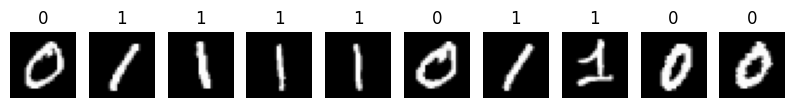

In [14]:
plt.figure(figsize=(10,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

Sample handwritten images of digits 0 and 1 from the MNIST dataset.

4.Train Logistic Regression

In [15]:
# Flatten images
x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

# Create model
classifier = LogisticRegression(max_iter=1000)

# Train
classifier.fit(x_train_flat, y_train)

# Predict
predictions = classifier.predict(x_test_flat)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9995271867612293


5.Show predictions

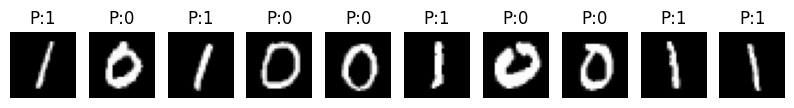

In [16]:
plt.figure(figsize=(10,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"P:{pred[i]}")
    plt.axis("off")

plt.show()

6.Generative Model

In [19]:
# Flatten for neural network
x_train_flat = x_train.reshape(-1,784)
x_test_flat = x_test.reshape(-1,784)

# Encoder
input_img = Input(shape=(784,))
encoded = Dense(32, activation="relu")(input_img)

# Decoder
decoded = Dense(784, activation="sigmoid")(encoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

7.Train it

In [20]:
history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4459 - val_loss: 0.2404
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2010 - val_loss: 0.1756
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1655 - val_loss: 0.1530
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1474 - val_loss: 0.1405
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1382 - val_loss: 0.1337
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1322 - val_loss: 0.1280
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1268 - val_loss: 0.1228
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1218 - val_loss: 0.1182
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1173 - val_loss: 0.1138
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1131 - val_loss: 0.1098


8.Plot Training Loss

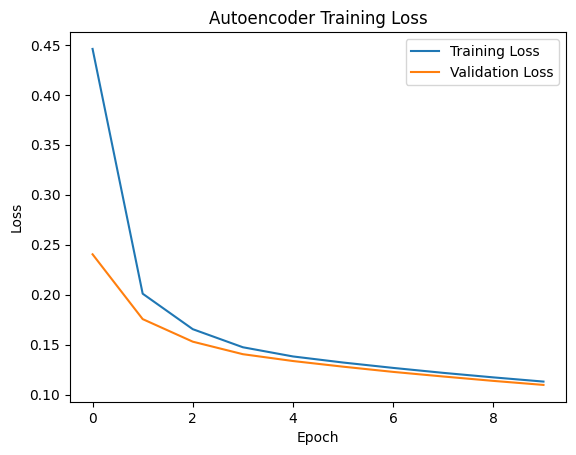

In [21]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()

plt.show()

9.Generate New Digit Images


In [22]:
generated = autoencoder.predict(x_test_flat[:10])

generated = generated.reshape(-1,28,28)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


10.Compare Real vs Generated Images

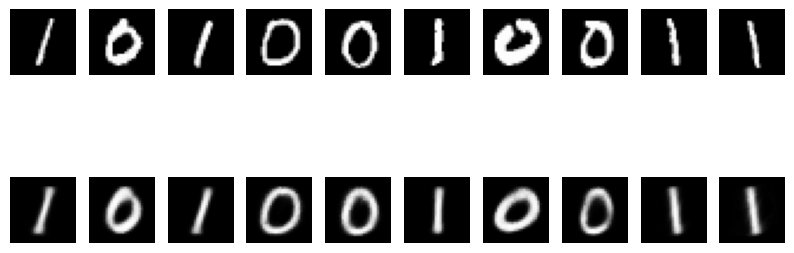

In [23]:
plt.figure(figsize=(10,4))

for i in range(10):

    # Real image
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")

    # Generated image
    plt.subplot(2,10,i+11)
    plt.imshow(generated[i], cmap="gray")
    plt.axis("off")

plt.show()

The discriminative model learned to classify handwritten digits 0 and 1. It predicts the correct label for each image with high accuracy. The generative model learned the patterns of the digits and reconstructed similar images. The main difference is that one classifies, while the other generates images.

 **comparison**


 |
discriminative              

*   Classifiy Images            
*   Output=0 & 1
*   Logistic regression
*   Learn decision boundary
                         
generative
*   Learns image patterns
*   Output = New/Reconstructed image
*   Autoencoder
*   Learns data distribution





